In [1]:
# import os

# os.environ["CUDA_VISIBLE_DEVICES"] = "1"
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
# import jax
# import jax.numpy as jnp
# from jax import grad, vmap, random
# import optax
# from seaborn import kdeplot
# import wandb
# from ot.lp import wasserstein_1d
# import argparse
# import pickle

from triangular_transport.flows.flow_trainer import (
    NNTrainer,
)

from triangular_transport.flows.interpolants import (
    linear_interpolant,
    linear_interpolant_der,
    trig_interpolant,
    trig_interpolant_der,
    sigmoid_interpolant,
    sigmoid_interpolant_der,
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.networks.flow_networks import MLP
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
)

from triangular_transport.kernels.kernel_tools import (
    get_gaussianRBF,
    vectorize_kfunc,
    get_sum_of_kernels,
)

plt.style.use("ggplot")

/home/verano13/miniconda3/envs/stochastic-interpolants/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


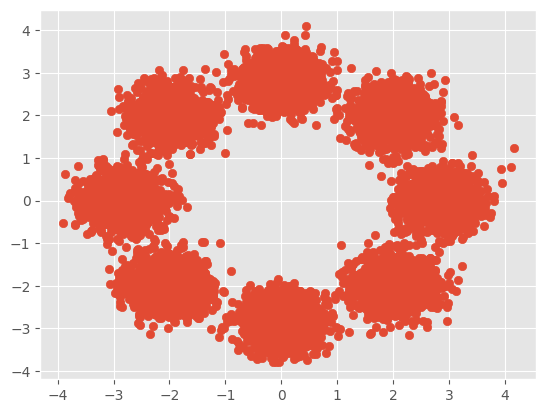

In [2]:
x1 = inf_train_gen(data="8gaussians", batch_size=10000)
plt.scatter(x1[:, 0], x1[:, 1])

In [3]:
x1

array([[-2.983352  ,  0.25207505],
       [-0.2897358 ,  2.8336792 ],
       [-2.2951775 , -2.0808015 ],
       ...,
       [ 1.5116508 ,  1.9353366 ],
       [ 3.1046133 ,  0.32261106],
       [-2.2900143 ,  0.23699255]], shape=(10000, 2), dtype=float32)

In [4]:
mean = np.mean(x1[:, 1])
var = np.std(x1[:, 1])
print(mean, var)

-0.02342355 2.0318456


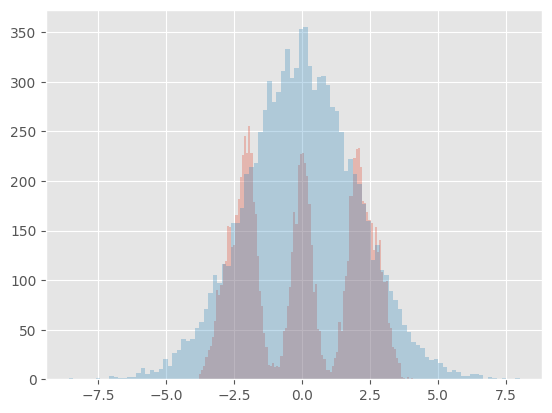

In [5]:
plt.hist(x1[:, 1], bins=100, alpha=0.3, label="8gaussians");
plt.hist(mean + var * np.random.randn(10000), bins=100, alpha=0.3, label="normal");

In [6]:
def eight_gaussians_density(x):
    scale = 4.0
    centers = [
            (1, 0),
            (-1, 0),
            (0, 1),
            (0, -1),
            (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        ]
    centers = [(scale * x, scale * y) for x, y in centers]
    factor = 2 / np.pi
    y, u = x[0], x[1]
    norm_part = np.array([((y - mu1) ** 2) + (u - mu2) ** 2 for mu1, mu2 in centers], dtype="float32")
    exp_part = np.exp(-scale * norm_part)
    sum_part = np.sum(exp_part)
    return factor * sum_part

def eight_gaussians_cond(u):
    scale = 4.0
    u = np.asarray(u)
    if u.ndim > 0:
        u = u.item()
    y = cond_variable
    y = float(np.asarray(y).item())
    centers = [
            (1, 0),
            (-1, 0),
            (0, 1),
            (0, -1),
            (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        ]
    centers = np.array([((scale * x) / np.sqrt(2), (scale * y) / (np.sqrt(2))) for x, y in centers], dtype="float32")
    factor = 1 / np.sqrt(np.pi)
    x = np.array([y, u])
    x = np.full((8, 2), fill_value=x)
    norm_part = np.sum((x - centers) * (x - centers), axis=1)
    exp_part = np.exp(-scale * norm_part)
    sum_part = np.sum(exp_part)
    return (factor * sum_part).item()

def log_eight_gaussians_cond(u):
    return float(np.log(eight_gaussians_cond(u)))
    

In [8]:
cond_variable = 0.0
xs = np.linspace(-6, 6, num=400)
cond_dens = []
for x in xs:
    cond_dens.append(eight_gaussians_cond(x))

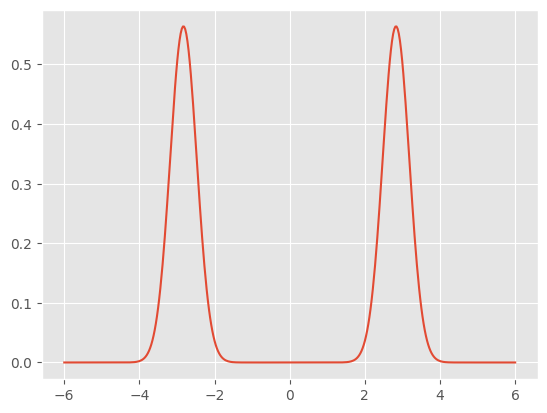

In [9]:
plt.plot(xs, cond_dens)

In [10]:
from emcee import EnsembleSampler

nwalkers = 16
ndim = 1
nsteps = 25000
initial = np.random.randn(nwalkers, ndim)
sampler = EnsembleSampler(nwalkers, ndim, log_eight_gaussians_cond)
sampler.run_mcmc(initial, nsteps, progress=True);

100%|██████████| 25000/25000 [00:12<00:00, 1950.15it/s]


<Axes: ylabel='Density'>

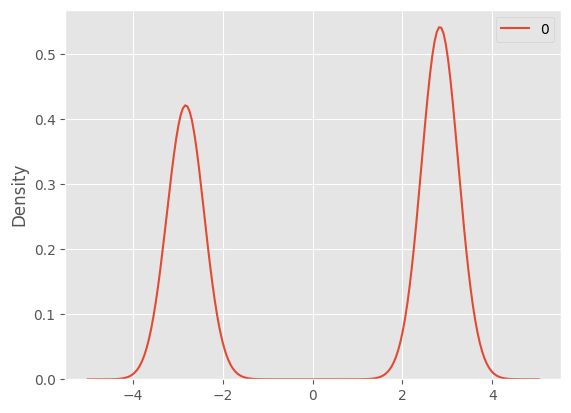

In [11]:
from seaborn import kdeplot
kdeplot(np.vstack(sampler.chain))

In [12]:
tau = 5.0
cond_variable = 0.0
from scipy.optimize import minimize_scalar

def log_gauss(u):
    # u = float(u)
    # IMPORTANT: include normalization if you want M for rejection sampling
    return -0.5*(u*u)/(tau*tau) - 0.5*np.log(2*np.pi*tau*tau)

def neg_log_ratio(u):
    return -(log_eight_gaussians_cond(u) - log_gauss(u))


res = minimize_scalar(neg_log_ratio, bounds=(-50, 50), method="bounded")
u_star = res.x
max_log_ratio = -res.fun
M = np.exp(max_log_ratio)

/tmp/ipykernel_2212503/1731938589.py:48: RuntimeWarning: divide by zero encountered in log
  return float(np.log(eight_gaussians_cond(u)))


In [13]:
log_gauss(1.0)

np.float64(-2.548376445638773)

In [14]:
neg_log_ratio(1.0)

np.float64(11.393927135415295)

In [15]:
def rejection_sample(n, tau=5.0, bounds=(-50, 50), batch=4096, seed=0):
    rng = np.random.default_rng(seed)

    log_m = np.log(M)
    samples = []
    n_accepted = 0
    n_total = 0

    while n_accepted < n:
        # propose a batch from q
        u_prop = rng.normal(loc=0.0, scale=tau, size=batch)

        # log acceptance ratios
        log_alpha = np.array([log_eight_gaussians_cond(u) - log_gauss(u) - log_m for u in u_prop])

        # accept with probability exp(log_alpha) (clipped at 1 for safety)
        alpha = np.exp(np.minimum(log_alpha, 0.0))
        u = rng.uniform(size=batch)
        accept = u < alpha

        accepted = u_prop[accept]
        samples.append(accepted)

        n_total += batch
        n_accepted += accepted.size

    samples = np.concatenate(samples)[:n]
    accept_rate = n / n_total

    return samples, accept_rate

samps, accept_rate = rejection_sample(50000)

/tmp/ipykernel_2209035/1731938589.py:48: RuntimeWarning: divide by zero encountered in log
  return float(np.log(eight_gaussians_cond(u)))


In [22]:
max_log_ratio

np.float64(2.11681553046876)

In [17]:
M

np.float64(8.30464943178533)

In [118]:
np.save("rej_samples_3.npy", samps)

In [16]:
accept_rate

0.11851486650485436

<Axes: ylabel='Density'>

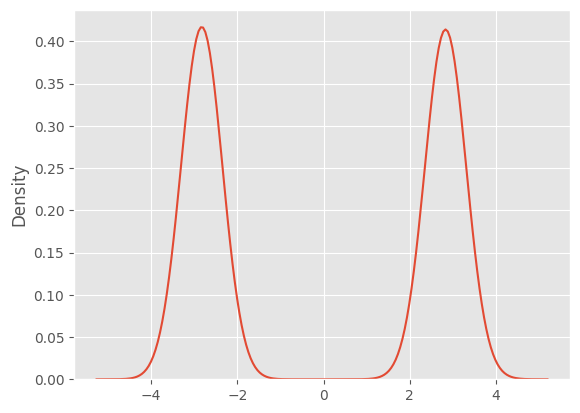

In [18]:
kdeplot(samps)

In [9]:
np.load("mcmc_results_0/avg_wd_mcmc.npy")

array([1.58543085, 1.03700116, 0.66545814, 0.49290094, 0.43726828,
       0.34296196, 0.39805057, 0.52804476, 0.5757231 , 0.43032065,
       0.35290002, 0.22078876, 0.1588675 , 0.12197395, 0.09196771,
       0.06556459, 0.06127167, 0.04397688, 0.03673451, 0.04040778,
       0.03492597, 0.0353009 , 0.03680019])

In [24]:
si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_3/run_{i:02d}/nn_conv_wd_{i}.npy")
si_mean = np.mean(si_array, axis=0)

In [18]:
import pandas as pd
si_mean3 = pd.read_csv("/home/verano13/TransportVsMcmcExperiments_fix/8gaussians/ode_3.csv")
si_mean3 = si_mean3.iloc[:, 1].to_numpy()

si_mean0 = pd.read_csv("/home/verano13/TransportVsMcmcExperiments_fix/8gaussians/ode_0.csv")
si_mean0 = si_mean0.iloc[:, 1].to_numpy()

si_mean2 = pd.read_csv("/home/verano13/TransportVsMcmcExperiments_fix/8gaussians/ode_2.csv")
si_mean2 = si_mean2.iloc[:, 1].to_numpy()

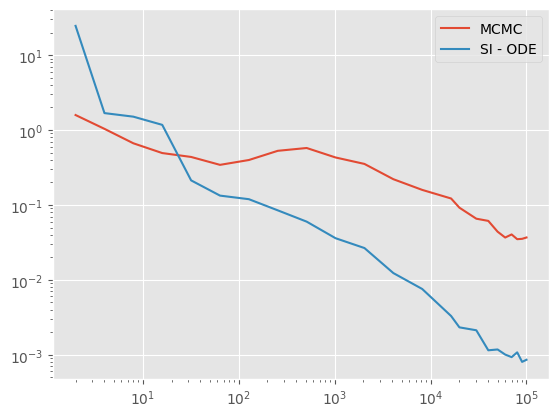

: 

In [ ]:
plt.plot(np.load("sample_no_list.npy"), np.load("mcmc_results_0/avg_wd_mcmc.npy"), label="MCMC")
plt.plot(np.load("sample_no_list.npy"), si_mean3, label="SI - ODE")
plt.xscale("log")
plt.yscale("log")
plt.legend()

In [140]:
samps0 = np.load("mcmc_results_0/mcmc_samps.npy")

<Axes: ylabel='Density'>

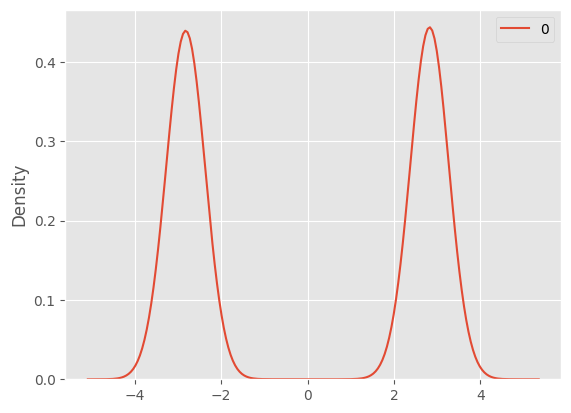

In [144]:
kdeplot(np.vstack(samps0[3]))

In [146]:
samps

array([ 0.52450059,  0.2066299 ,  0.47006149, ...,  0.5898108 ,
       -0.0643007 , -2.01927678], shape=(100000,))